<a href="https://colab.research.google.com/github/SAGNIK890/NXP-Aim-Buggy/blob/main/SpeechRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa

In [ ]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [ ]:
!unzip -o /content/drive/MyDrive/archive.zip

Archive:  /content/drive/MyDrive/archive.zip
  inflating: Actor_01/03-01-01-01-01-01-01.wav  
  inflating: Actor_01/03-01-01-01-01-02-01.wav  
  inflating: Actor_01/03-01-01-01-02-01-01.wav  
  inflating: Actor_01/03-01-01-01-02-02-01.wav  
  inflating: Actor_01/03-01-02-01-01-01-01.wav  
  inflating: Actor_01/03-01-02-01-01-02-01.wav  
  inflating: Actor_01/03-01-02-01-02-01-01.wav  
  inflating: Actor_01/03-01-02-01-02-02-01.wav  
  inflating: Actor_01/03-01-02-02-01-01-01.wav  
  inflating: Actor_01/03-01-02-02-01-02-01.wav  
  inflating: Actor_01/03-01-02-02-02-01-01.wav  
  inflating: Actor_01/03-01-02-02-02-02-01.wav  
  inflating: Actor_01/03-01-03-01-01-01-01.wav  
  inflating: Actor_01/03-01-03-01-01-02-01.wav  
  inflating: Actor_01/03-01-03-01-02-01-01.wav  
  inflating: Actor_01/03-01-03-01-02-02-01.wav  
  inflating: Actor_01/03-01-03-02-01-01-01.wav  
  inflating: Actor_01/03-01-03-02-01-02-01.wav  
  inflating: Actor_01/03-01-03-02-02-01-01.wav  
  inflating: Actor_01/03

In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip -d /content/RAVDESS

In [ ]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [ ]:
X = []
y = []

DATASET_PATH = "/content/RAVDESS"
for actor in os.listdir(DATASET_PATH):
    actor_path = os.path.join(DATASET_PATH, actor)

    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            path = os.path.join(actor_path, file)

            emotion = emotion_dict[file.split("-")[2]]

            try:
                features = extract_features(path)
                X.append(features)
                y.append(emotion)
            except:
                pass

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

Feature shape: (1440, 26)


In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1152, 26)
Test shape: (288, 26)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5416666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.47      0.52        38
           1       0.57      0.79      0.66        38
           2       0.48      0.63      0.55        38
           3       0.56      0.49      0.52        39
           4       0.55      0.46      0.50        39
           5       0.62      0.42      0.50        19
           6       0.49      0.45      0.47        38
           7       0.56      0.56      0.56        39

    accuracy                           0.54       288
   macro avg       0.55      0.53      0.53       288
weighted avg       0.55      0.54      0.54       288



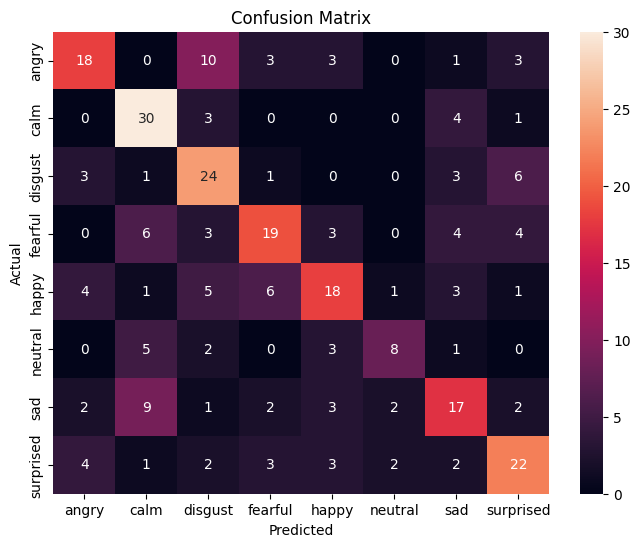

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 03-01-04-02-02-02-01.wav to 03-01-04-02-02-02-01 (1).wav


In [ ]:
os.rename("03-01-04-02-02-02-01 (1).wav","test.wav")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
def predict_emotion(file_path):
    features = extract_features(file_path)   # MFCC extraction
    features = scaler.transform([features])  # normalize

    pred = model.predict(features)
    emotion = encoder.inverse_transform(pred)[0]

    return emotion

In [ ]:
print("Predicted Emotion:", predict_emotion("test.wav"))

Predicted Emotion: sad


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def show_mfcc(file_path):
    signal, sr = librosa.load(file_path, sr=None)

    # Extract MFCC
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

    # Plot MFCC
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time')
    plt.colorbar()
    plt.title("MFCC Features")
    plt.tight_layout()
    plt.show()

    return mfcc

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving listener-discretion-advised-male-podcast-intro-voice-jam-fx-long-2-00-05.mp3 to listener-discretion-advised-male-podcast-intro-voice-jam-fx-long-2-00-05.mp3


In [ ]:
predict_emotion("listener-discretion-advised-male-podcast-intro-voice-jam-fx-long-2-00-05.mp3")

np.str_('angry')

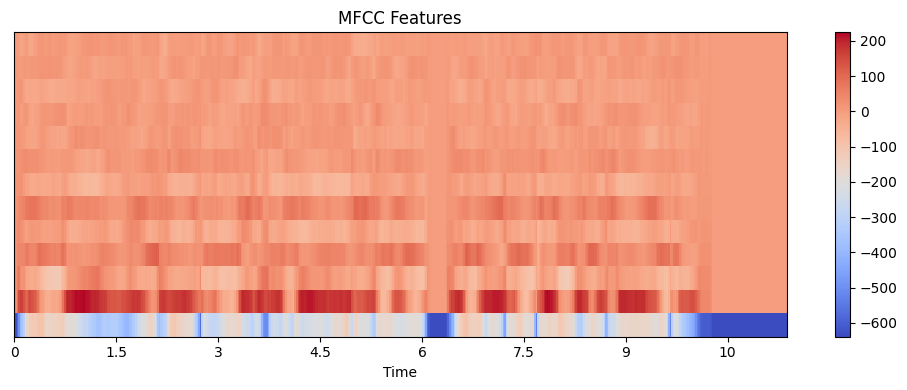

array([[-636.90424  , -620.2043   , -575.34     , ..., -639.1286   ,
        -639.1286   , -639.1286   ],
       [   3.128707 ,   26.415993 ,   81.00716  , ...,    0.       ,
           0.       ,    0.       ],
       [   3.0778458,   25.408947 ,   61.024693 , ...,    0.       ,
           0.       ,    0.       ],
       ...,
       [   1.64832  ,    7.46782  ,    7.067215 , ...,    0.       ,
           0.       ,    0.       ],
       [   1.3830323,    5.5428553,    8.575838 , ...,    0.       ,
           0.       ,    0.       ],
       [   1.1102946,    3.965427 ,    7.249203 , ...,    0.       ,
           0.       ,    0.       ]], dtype=float32)

In [ ]:
show_mfcc("listener-discretion-advised-male-podcast-intro-voice-jam-fx-long-2-00-05.mp3")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving snickering-laugh-female-tomas-herudek-long-1-00-03.mp3 to snickering-laugh-female-tomas-herudek-long-1-00-03.mp3


In [ ]:
import os
from pydub import AudioSegment

input_mp3_filename = "snickering-laugh-female-tomas-herudek-long-1-00-03.mp3"
output_wav = "snickering-laugh-female-tomas-herudek-long-1-00-03.wav"


if not os.path.exists(input_mp3_filename):
    if input_mp3_filename in uploaded:
        print(f"File '{input_mp3_filename}' not found on disk, but found in 'uploaded' dictionary. Writing to disk...")
        with open(input_mp3_filename, 'wb') as f:
            f.write(uploaded[input_mp3_filename])
    else:
        raise FileNotFoundError(f"Error: File '{input_mp3_filename}' not found on disk and not in 'uploaded' dictionary. Please ensure the file is uploaded.")

audio = AudioSegment.from_mp3(input_mp3_filename)
audio.export(output_wav, format="wav")

print("Predicted Emotion:", predict_emotion(output_wav))

Predicted Emotion: fearful


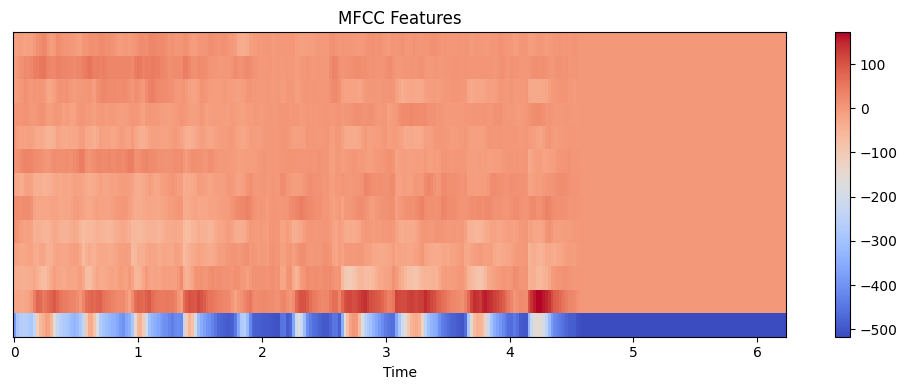

array([[-3.8049741e+02, -2.8750653e+02, -2.6467188e+02, ...,
        -5.1684326e+02, -5.1684326e+02, -5.1684326e+02],
       [-2.1314499e+01, -2.0869640e+01, -2.5327583e+01, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-3.1549822e+01, -3.6427673e+01, -3.7214622e+01, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       ...,
       [-1.0469467e+01, -5.0216923e+00, -4.7144040e-01, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-1.1670746e+01,  3.7647486e-01,  1.0338537e+01, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-1.5741417e+01, -1.1674228e+01, -7.0370426e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)

In [ ]:
show_mfcc("snickering-laugh-female-tomas-herudek-long-1-00-03.wav")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving shut-up-angry-man-yelling-impact-soundroll-1-00-02.mp3 to shut-up-angry-man-yelling-impact-soundroll-1-00-02.mp3


Predicted Emotion: angry


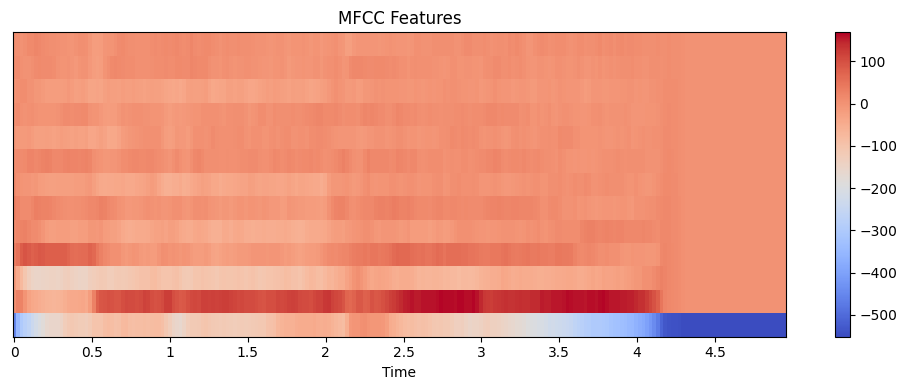

array([[-451.14835  , -348.57672  , -298.80035  , ..., -551.5178   ,
        -551.5178   , -551.5178   ],
       [   6.068859 ,   28.137518 ,   25.250702 , ...,    0.       ,
           0.       ,    0.       ],
       [ -12.953463 ,  -44.531498 ,  -75.664314 , ...,    0.       ,
           0.       ,    0.       ],
       ...,
       [  -2.8732953,    3.982198 ,    9.593821 , ...,    0.       ,
           0.       ,    0.       ],
       [  10.865967 ,   13.208868 ,    2.9897099, ...,    0.       ,
           0.       ,    0.       ],
       [   7.1785517,    5.714719 ,    1.3601943, ...,    0.       ,
           0.       ,    0.       ]], dtype=float32)

In [ ]:
import os
from pydub import AudioSegment

input_mp3_filename = "shut-up-angry-man-yelling-impact-soundroll-1-00-02.mp3"



if not os.path.exists(input_mp3_filename):
    if input_mp3_filename in uploaded:
        print(f"File '{input_mp3_filename}' not found on disk, but found in 'uploaded' dictionary. Writing to disk...")
        with open(input_mp3_filename, 'wb') as f:
            f.write(uploaded[input_mp3_filename])
    else:
        raise FileNotFoundError(f"Error: File '{input_mp3_filename}' not found on disk and not in 'uploaded' dictionary. Please ensure the file is uploaded.")

audio = AudioSegment.from_mp3(input_mp3_filename)
audio.export(output_wav, format="wav")

print("Predicted Emotion:", predict_emotion(output_wav))
show_mfcc(output_wav)

Predicted Emotion: sad


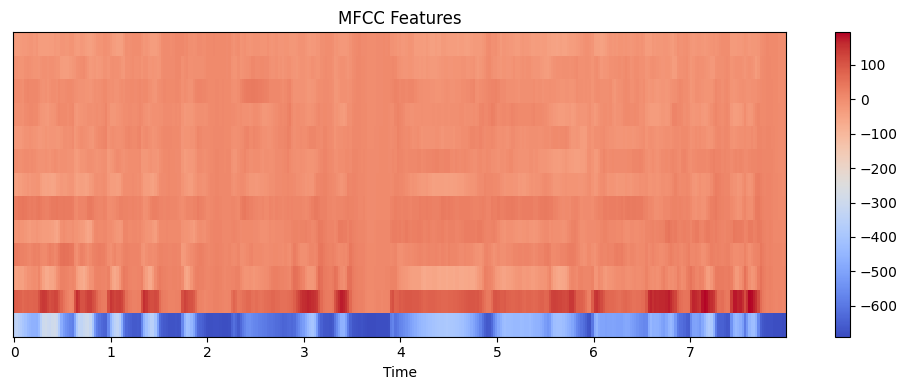

array([[-3.55322479e+02, -3.39809509e+02, -3.58557068e+02, ...,
        -6.85471191e+02, -6.86822998e+02, -6.83537476e+02],
       [ 9.51918640e+01,  8.74331360e+01,  8.41344070e+01, ...,
         1.23926849e+01,  1.04686813e+01,  1.49496469e+01],
       [-2.99181557e+01, -4.44438477e+01, -4.20703163e+01, ...,
         1.06800804e+01,  8.74321651e+00,  1.28079863e+01],
       ...,
       [ 7.53193760e+00,  2.42148209e+00,  3.92379522e+00, ...,
         1.06619373e-02,  9.37087476e-01,  2.12664127e+00],
       [-9.20082283e+00, -1.25717125e+01, -1.40374222e+01, ...,
         4.35362846e-01,  8.41511846e-01,  5.49925864e-01],
       [-3.05182056e+01, -3.41688385e+01, -3.59151497e+01, ...,
         8.20477188e-01,  2.76916504e-01, -1.38296223e+00]], dtype=float32)

In [ ]:
import os
from pydub import AudioSegment

input_mp3_filename = "Voice 9.mp3"


if not os.path.exists(input_mp3_filename):
    if input_mp3_filename in uploaded:
        print(f"File '{input_mp3_filename}' not found on disk, but found in 'uploaded' dictionary. Writing to disk...")
        with open(input_mp3_filename, 'wb') as f:
            f.write(uploaded[input_mp3_filename])
    else:
        raise FileNotFoundError(f"Error: File '{input_mp3_filename}' not found on disk and not in 'uploaded' dictionary. Please ensure the file is uploaded.")

audio = AudioSegment.from_mp3(input_mp3_filename)
audio.export(output_wav, format="wav")

print("Predicted Emotion:", predict_emotion(output_wav))
show_mfcc(output_wav)